In [23]:
import pandas as pd
import json

def load_and_clean(path, suffix):
    with open(path, 'r') as f:
        data = json.load(f)
    df = pd.DataFrame.from_dict(data, orient='index').reset_index(drop=True)
    # 4.5.3: Handle malformed timestamps and convert to datetime
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
    df = df.dropna(subset=['Timestamp']).sort_values('Timestamp')
    return df[['Timestamp', 'WaterLevel', 'RainRate']].rename(
        columns={'WaterLevel': f'WL_{suffix}', 'RainRate': f'RR_{suffix}'}
    )

# Load Node 1 (Upstream) and Node 2 (Downstream)
df1 = load_and_clean('data/node1.json', 'N1')
df2 = load_and_clean('data/node2.json', 'N2')

# 4.5.4: Align by timestamp (Smart Merge)
df_final = pd.merge_asof(df2, df1, on='Timestamp', direction='nearest', tolerance=pd.Timedelta('1m')).dropna()
print(f"Data synchronized. Total rows: {len(df_final)}")

Data synchronized. Total rows: 932


In [24]:
# 4.5.5: Resample to 1-minute intervals (Interpolate small gaps)
df_final = df_final.set_index('Timestamp').resample('1min').mean().interpolate(limit=5).dropna()

# 4.5.6: Dual-Window Smoothing (Median Filter)
# Node 1 (Upstream) = Larger window (5 min); Node 2 (Downstream) = Smaller window (3 min)
df_final['WL_N1_smooth'] = df_final['WL_N1'].rolling(window=5, center=True).median()
df_final['WL_N2_smooth'] = df_final['WL_N2'].rolling(window=3, center=True).median()
df_final = df_final.dropna()

In [25]:
# 1. Trends: Rate of Change
df_final['Trend_N1'] = df_final['WL_N1_smooth'].diff()
df_final['Trend_N2'] = df_final['WL_N2_smooth'].diff()

# 2. Differences: Spatial Gradient
df_final['WL_Diff'] = df_final['WL_N1_smooth'] - df_final['WL_N2_smooth']

# 3. Lag Features: Values from 5, 10, and 15 mins ago
for lag in [5, 10, 15]:
    df_final[f'WL_N2_lag{lag}'] = df_final['WL_N2_smooth'].shift(lag)

# 4. TARGET: Prediction for 5 minutes into the future
df_final['Target_WL_N2'] = df_final['WL_N2_smooth'].shift(-5)

df_ready = df_final.dropna()
print("Features created. Ready for LSTM training.")
print(df_ready.columns.tolist())

Features created. Ready for LSTM training.
['WL_N2', 'RR_N2', 'WL_N1', 'RR_N1', 'WL_N1_smooth', 'WL_N2_smooth', 'Trend_N1', 'Trend_N2', 'WL_Diff', 'WL_N2_lag5', 'WL_N2_lag10', 'WL_N2_lag15', 'Target_WL_N2']


In [26]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Select the features you decided on in Step 3
features = ['WL_N1_smooth', 'WL_N2_smooth', 'RR_N1', 'RR_N2', 'Trend_N1', 'Trend_N2', 'WL_Diff', 'WL_N2_lag5', 'WL_N2_lag10', 'WL_N2_lag15']
target = ['Target_WL_N2']

# Initialize Scalers
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

# Fit and Transform
scaled_x = scaler_x.fit_transform(df_ready[features])
scaled_y = scaler_y.fit_transform(df_ready[target])

print("Data normalized. Scale is now 0 to 1.")

Data normalized. Scale is now 0 to 1.


In [27]:
def create_sequences(data, target, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i : i + seq_length])
        y.append(target[i + seq_length])
    return np.array(X), np.array(y)

# Create the 3D sequences for the LSTM
X, y = create_sequences(scaled_x, scaled_y, seq_length=6)

print(f"Sequences created. Shape of X: {X.shape}") # Should be (Samples, 6, 10)

Sequences created. Shape of X: (3746, 6, 10)


In [32]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout  # <--- Added Dropout here

model = Sequential([
    # Input Layer: 64 units
    # Note: We keep return_sequences=True because the next layer is also an LSTM
    LSTM(64, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    
    # Dropout layer: 20% of neurons will be randomly "turned off" during training
    # This forces the model to learn more robust patterns and reduces overfitting
    Dropout(0.2), 
    
    # Hidden Layer: 32 units
    LSTM(32, return_sequences=False),
    
    # Output Layer: 1 unit for WaterLevel_N2 prediction
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# Train the model
# Increasing epochs slightly might help now that you have Dropout
history = model.fit(X, y, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0667 - val_loss: 0.0232
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0229 - val_loss: 0.0234
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0219 - val_loss: 0.0223
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0216 - val_loss: 0.0238
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0211 - val_loss: 0.0246
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0207 - val_loss: 0.0232
Epoch 7/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0203 - val_loss: 0.0220
Epoch 8/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0201 - val_loss: 0.0226
Epoch 9/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0200 - val_loss: 0.0225
Epoch 10/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0196 - val_loss: 0.0206
Epoch 11/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0204 - val_loss: 0.0229
Epoch 12/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0188 - val_l

118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


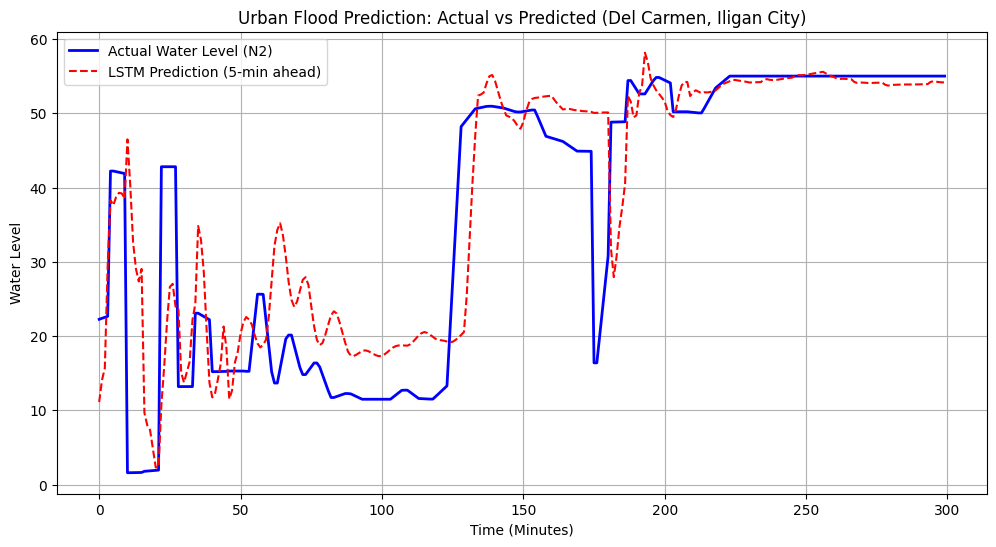

In [33]:
import matplotlib.pyplot as plt

# 1. Make predictions
predictions_scaled = model.predict(X)

# 2. Reverse the scaling so we see actual cm/meters, not 0 to 1
predictions = scaler_y.inverse_transform(predictions_scaled)
actuals = scaler_y.inverse_transform(y)

# 3. Plot a segment of the results (e.g., first 300 minutes)
plt.figure(figsize=(12, 6))
plt.plot(actuals[:300], label='Actual Water Level (N2)', color='blue', linewidth=2)
plt.plot(predictions[:300], label='LSTM Prediction (5-min ahead)', color='red', linestyle='--')
plt.title('Urban Flood Prediction: Actual vs Predicted (Del Carmen, Iligan City)')
plt.xlabel('Time (Minutes)')
plt.ylabel('Water Level')
plt.legend()
plt.grid(True)
plt.show()

In [34]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(actuals, predictions))
mae = mean_absolute_error(actuals, predictions)

print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")

Root Mean Squared Error: 6.5302
Mean Absolute Error: 3.1529


In [37]:
model.save('models/flood_prediction_model_new.keras')
print("Model saved successfully to 'models/flood_prediction_model_new.keras'")

Model saved successfully to 'models/flood_prediction_model_new.keras'
